In [1]:
from IPython.display import HTML, display
display(HTML("""
<style>
body, .jp-Notebook { font-family: 'Segoe UI', Arial, sans-serif; }
h1 { color: #1a1a2e; border-bottom: 3px solid #e74c3c; padding-bottom: 8px; }
h2 { color: #16213e; border-left: 5px solid #e74c3c; padding-left: 12px; }
h3 { color: #0f3460; }
.callout { background:#e8f4fd; border-left:4px solid #3498db; padding:12px 16px; border-radius:4px; margin:10px 0; }
.warning  { background:#fff3cd; border-left:4px solid #f39c12; padding:12px 16px; border-radius:4px; margin:10px 0; }
.success  { background:#d4edda; border-left:4px solid #27ae60; padding:12px 16px; border-radius:4px; margin:10px 0; }
table     { border-collapse:collapse; width:100%; }
th        { background:#1a1a2e; color:white; padding:8px 12px; }
td        { padding:7px 12px; border-bottom:1px solid #ddd; }
tr:nth-child(even) { background:#f8f9fa; }
</style>
"""))


# 🛍️ Dolap İlan Satış Tahmini
## Exploratory Data Analysis — Feature Engineering Report

### Öğrenci:  
### Proje Başlığı: Dolap'ta İlanın 7 Gün İçinde Satılıp Satılamayacağının Tahmini

<div class="callout">
<b>Bu notebook hakkında</b><br>
Bu analiz, Dolap.com'dan scrape edilen ikinci el giyim ilanları verisi üzerine yapılan tam bir EDA sürecini kapsar.
Amaç: <b>bir ilanın yayınlandıktan sonra 7 gün içinde satılıp satılmayacağını</b> tahmin eden bir ML modeli için
en güçlü özellikleri keşfetmek ve üretmektir.<br><br>
<b>Bölümler:</b> Problem Tanımı → Veri Keşfi → Temizleme → Feature Engineering → Görselleştirme → Preprocessing
</div>


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

# ── Stil ayarları ──────────────────────────────────────────────────────────
PALETTE   = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6", "#1abc9c"]
RED, BLUE, GREEN, ORANGE = "#e74c3c", "#3498db", "#2ecc71", "#f39c12"
DARK      = "#1a1a2e"
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})

print("✅  Kütüphaneler yüklendi.")


✅  Kütüphaneler yüklendi.


---
## Bölüm 1 — Problem Tanımı

| Soru | Cevap |
|---|---|
| **Neden?** | Satıcılar ilanlarını optimize etmek, alıcılar iyi fırsatları kaçırmamak ister. |
| **Ne tahmin ediyoruz?** | İkili sınıflandırma: `sold_within_7_days` (1 = 7 günde satıldı, 0 = satılmadı) |
| **Girdi verimiz neler?** | İlan fiyatı, fotoğraf sayısı, satıcı profili, ürün durumu, açıklama, sevkiyat bilgisi, vb. |
| **Başarı metriği?** | F1-score (dengesiz sınıf nedeniyle), ROC-AUC |

<div class="warning">
<b>Veri Sızıntısı Uyarısı:</b> <code>is_sold</code>, <code>status</code>, <code>label_status</code> kolonları hedef değişkenle doğrudan ilişkilidir.
Bu kolonlar preprocessing sırasında modelden <b>dışlanmalıdır</b>.
</div>


In [3]:
# ── Veri yükleme ──────────────────────────────────────────────────────────
df_raw = pd.read_csv("../data/interim/merged_data.csv")   # ← gerçek veride yolu değiştirin
df     = df_raw.copy()

print(f"📦  Satır sayısı : {df.shape[0]:,}")
print(f"📊  Kolon sayısı : {df.shape[1]}")
print(f"🎯  Hedef dağılımı:\n{df['sold_within_7_days'].value_counts(dropna=False).to_string()}")


📦  Satır sayısı : 6,059
📊  Kolon sayısı : 42
🎯  Hedef dağılımı:
sold_within_7_days
0.0    5125
NaN     587
1.0     347


---
## Bölüm 2 — Veri Tanıma

<div class="callout">
Veri, Dolap.com'dan scrape edilmiş ikinci el giyim ilanlarından oluşmaktadır.
Her satır bir ilanı, her kolon ise o ilana ait bir özelliği temsil eder.
</div>


In [4]:
# ── Şema ve veri tipleri ─────────────────────────────────────────────────
schema = pd.DataFrame({
    "Dtype"   : df.dtypes.astype(str),
    "Null #"  : df.isnull().sum(),
    "Null %"  : (df.isnull().mean() * 100).round(1),
    "Unique"  : df.nunique(),
    "Sample"  : df.iloc[0]
})
display(schema.style
        .background_gradient(subset=["Null %"], cmap="YlOrRd")
        .set_table_styles([{"selector":"th","props":[("background","#1a1a2e"),("color","white")]}]))


,Dtype,Null #,Null %,Unique,Sample
url,str,0,0.000000,6059,https://dolap.com/urun/h-m-mavi-jeans-yeni-etiketli-efnanindolabiii-445832624
listing_id,int64,0,0.000000,6059,445832624
category,str,43,0.700000,80,nan
subcategory,str,43,0.700000,15,nan
brand,str,0,0.000000,597,H&M - M / 38 Beden
title,str,0,0.000000,4109,H&M Mavi Jeans Yeni & Etiketli Online Satın Al
price,float64,0,0.000000,579,249.000000
original_price,float64,6035,99.600000,10,nan
has_discount,bool,0,0.000000,2,False
condition,str,0,0.000000,4,Yeni ve Etiketli


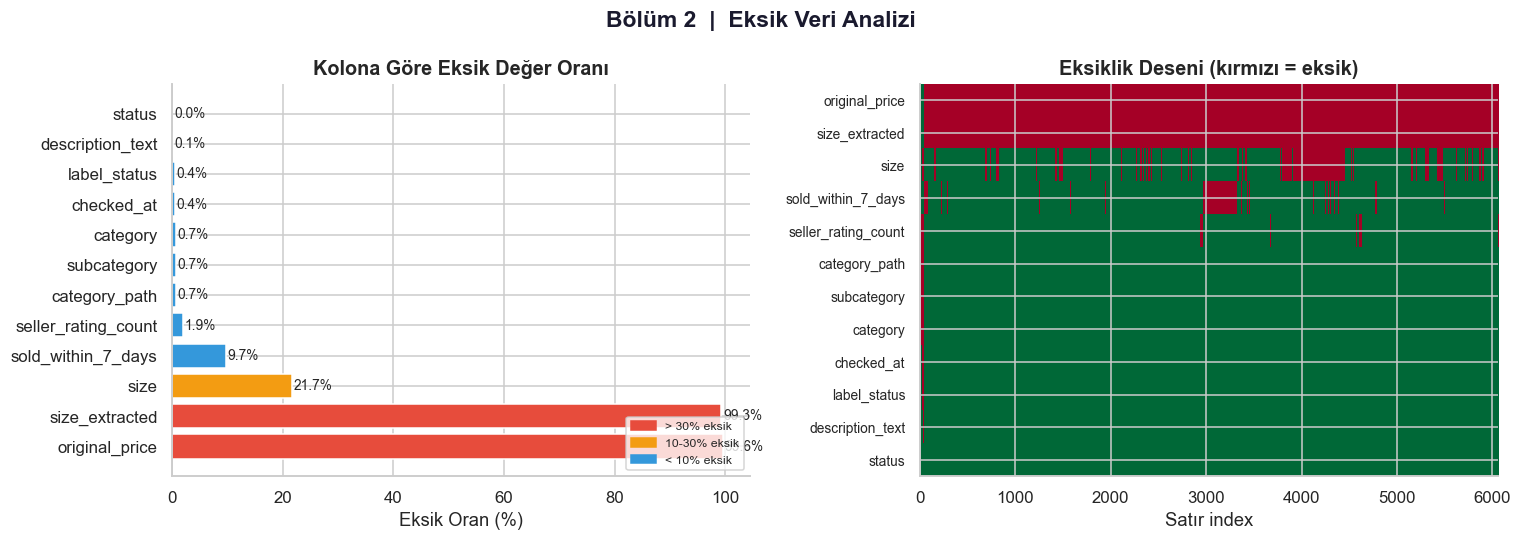

📌  Yorum: category ve category_path kolonları büyük ölçüde eksik —
    category_scraped kolonu bunların doldurulmuş versiyonudur, onu kullanacağız.


In [5]:
# ── Eksik değer görselleştirmesi ─────────────────────────────────────────
missing = df.isnull().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Bölüm 2  |  Eksik Veri Analizi", fontsize=15, fontweight="bold", color=DARK)

# Bar chart
colors = [RED if v > 30 else ORANGE if v > 10 else BLUE for v in missing.values]
axes[0].barh(missing.index, missing.values, color=colors)
axes[0].set_xlabel("Eksik Oran (%)")
axes[0].set_title("Kolona Göre Eksik Değer Oranı")
for i, v in enumerate(missing.values):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)

# Heatmap — missingness pattern
axes[1].imshow(df[missing.index].isnull().T.values, aspect="auto", cmap="RdYlGn_r",
               vmin=0, vmax=1, interpolation="nearest")
axes[1].set_yticks(range(len(missing.index)))
axes[1].set_yticklabels(missing.index, fontsize=9)
axes[1].set_xlabel("Satır index")
axes[1].set_title("Eksiklik Deseni (kırmızı = eksik)")

red_p  = mpatches.Patch(color=RED,    label="> 30% eksik")
orng_p = mpatches.Patch(color=ORANGE, label="10-30% eksik")
blue_p = mpatches.Patch(color=BLUE,   label="< 10% eksik")
axes[0].legend(handles=[red_p, orng_p, blue_p], loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig(Path("../artifacts/figures/eda/fig_missing_values.png"), bbox_inches="tight"); plt.show()
print("📌  Yorum: category ve category_path kolonları büyük ölçüde eksik —")
print("    category_scraped kolonu bunların doldurulmuş versiyonudur, onu kullanacağız.")


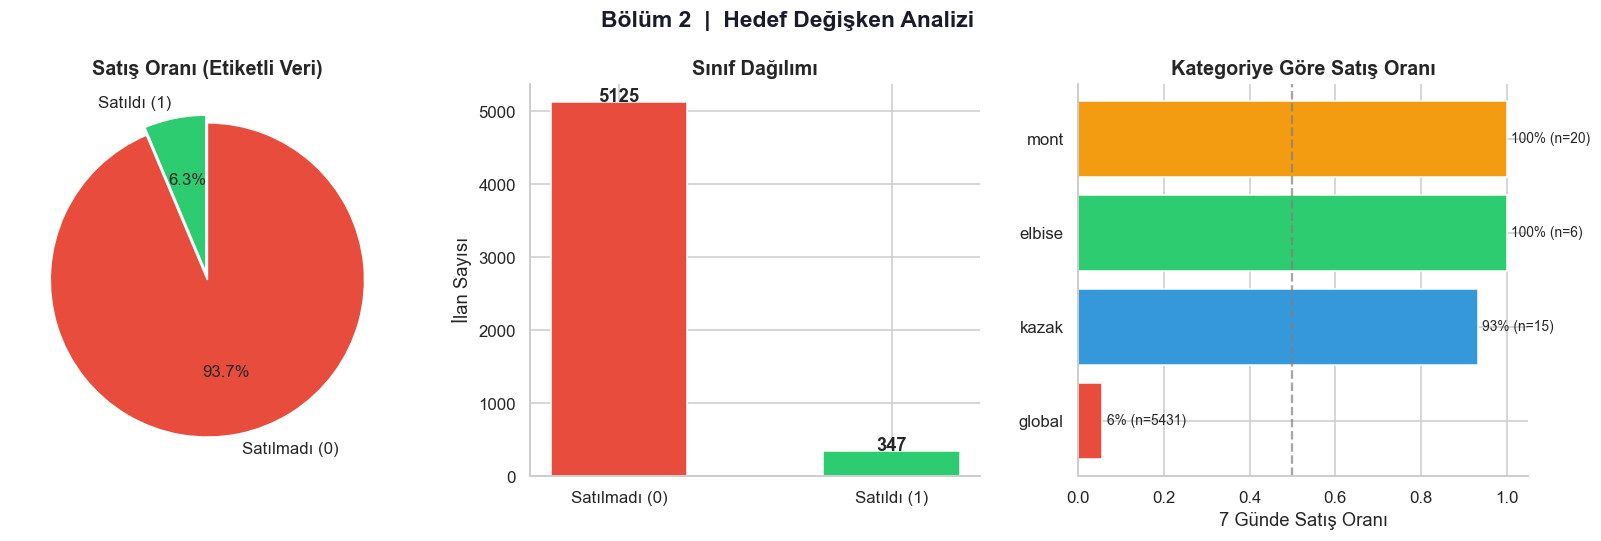


⚠️  Sınıf dengesizliği: Pozitif oranı = 6.3%
    Gerçek 6000 satırlık veri üzerinde bu oran kritik — model eğitiminde dengeleme gerekebilir.


In [6]:
# ── Hedef değişken dağılımı ──────────────────────────────────────────────
df_labeled = df.dropna(subset=["sold_within_7_days"]).copy()
df_labeled["sold_within_7_days"] = df_labeled["sold_within_7_days"].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Bölüm 2  |  Hedef Değişken Analizi", fontsize=15, fontweight="bold", color=DARK)

# Pie
labels_pie = ["Satıldı (1)", "Satılmadı (0)"]
sizes      = df_labeled["sold_within_7_days"].value_counts().sort_index(ascending=False).values
explode    = (0.05, 0)
axes[0].pie(sizes, labels=labels_pie, autopct="%1.1f%%", colors=[GREEN, RED],
            explode=explode, startangle=90, textprops={"fontsize": 11})
axes[0].set_title("Satış Oranı (Etiketli Veri)")

# Bar
counts = df_labeled["sold_within_7_days"].value_counts().sort_index()
axes[1].bar(["Satılmadı (0)", "Satıldı (1)"], counts.values, color=[RED, GREEN], edgecolor="white", width=0.5)
axes[1].set_title("Sınıf Dağılımı")
axes[1].set_ylabel("İlan Sayısı")
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

# Kategori bazlı satış oranı
cat_rate = (df_labeled.groupby("category_scraped")["sold_within_7_days"]
            .agg(["mean","count"]).rename(columns={"mean":"Oran","count":"N"})
            .sort_values("Oran", ascending=True))
axes[2].barh(cat_rate.index, cat_rate["Oran"], color=PALETTE[:len(cat_rate)])
axes[2].set_xlabel("7 Günde Satış Oranı")
axes[2].set_title("Kategoriye Göre Satış Oranı")
axes[2].axvline(0.5, color="gray", linestyle="--", alpha=0.7)
for i, (idx, row) in enumerate(cat_rate.iterrows()):
    axes[2].text(row["Oran"] + 0.01, i, f"{row['Oran']:.0%} (n={row['N']:.0f})", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(Path("../artifacts/figures/eda/fig_target_distribution.png"), bbox_inches="tight"); plt.show()
print(f"\n⚠️  Sınıf dengesizliği: Pozitif oranı = {df_labeled['sold_within_7_days'].mean():.1%}")
print("    Gerçek 6000 satırlık veri üzerinde bu oran kritik — model eğitiminde dengeleme gerekebilir.")


---
## Bölüm 3 — Sayısal Özellik Analizi (EDA)

<div class="callout">
Sayısal özellikler modelin ham hammaddesidir. Dağılımlarını, aykırı değerlerini
ve hedef değişkenle ilişkilerini incelemek, hangi özelliklerin anlamlı olduğunu ortaya koyar.
</div>


In [7]:
# ── Tanımlayıcı istatistikler ────────────────────────────────────────────
numeric_cols = ["price", "original_price", "description_length", "description_word_count",
                "photo_count", "like_count", "comment_count", "seller_listing_count",
                "seller_rating_count", "condition_ordinal"]

desc = df[numeric_cols].describe().T.round(2)
desc["IQR"]   = (desc["75%"] - desc["25%"]).round(2)
desc["CV %"]  = (desc["std"] / desc["mean"] * 100).round(1)
desc["Skew"]  = df[numeric_cols].skew().round(2)
desc["Kurt"]  = df[numeric_cols].kurt().round(2)

display(desc.style
        .background_gradient(subset=["CV %"], cmap="YlOrRd")
        .format(precision=2)
        .set_table_styles([{"selector":"th","props":[("background","#1a1a2e"),("color","white")]}]))


,count,mean,std,min,25%,50%,75%,max,IQR,CV %,Skew,Kurt
price,6059.00,599.48,1078.91,30.00,155.00,290.00,750.00,35000.00,595.00,180.00,12.19,264.79
original_price,24.00,2068.75,1276.95,950.00,1250.00,1500.00,3500.00,5000.00,2250.00,61.70,1.11,-0.28
description_length,6059.00,147.18,148.64,0.00,48.00,102.00,180.00,929.00,132.00,101.00,2.25,5.53
description_word_count,6059.00,20.64,19.06,0.00,8.00,15.00,26.00,133.00,18.00,92.30,2.09,4.86
photo_count,6059.00,5.60,2.03,0.00,4.00,6.00,7.00,14.00,3.00,36.20,-0.09,-0.87
like_count,6059.00,7.84,12.43,0.00,1.00,4.00,10.00,151.00,9.00,158.50,4.36,27.43
comment_count,6059.00,2.91,10.33,0.00,0.00,0.00,2.00,461.00,2.00,355.00,18.69,678.73
seller_listing_count,6059.00,1.61,42.62,0.00,0.00,0.00,0.00,1322.00,0.00,2647.20,30.12,920.32
seller_rating_count,5941.00,422.78,445.17,8.00,75.00,326.00,659.00,1970.00,584.00,105.30,1.65,2.70
condition_ordinal,6059.00,1.79,0.86,1.00,1.00,2.00,3.00,3.00,2.00,48.00,0.42,-1.52


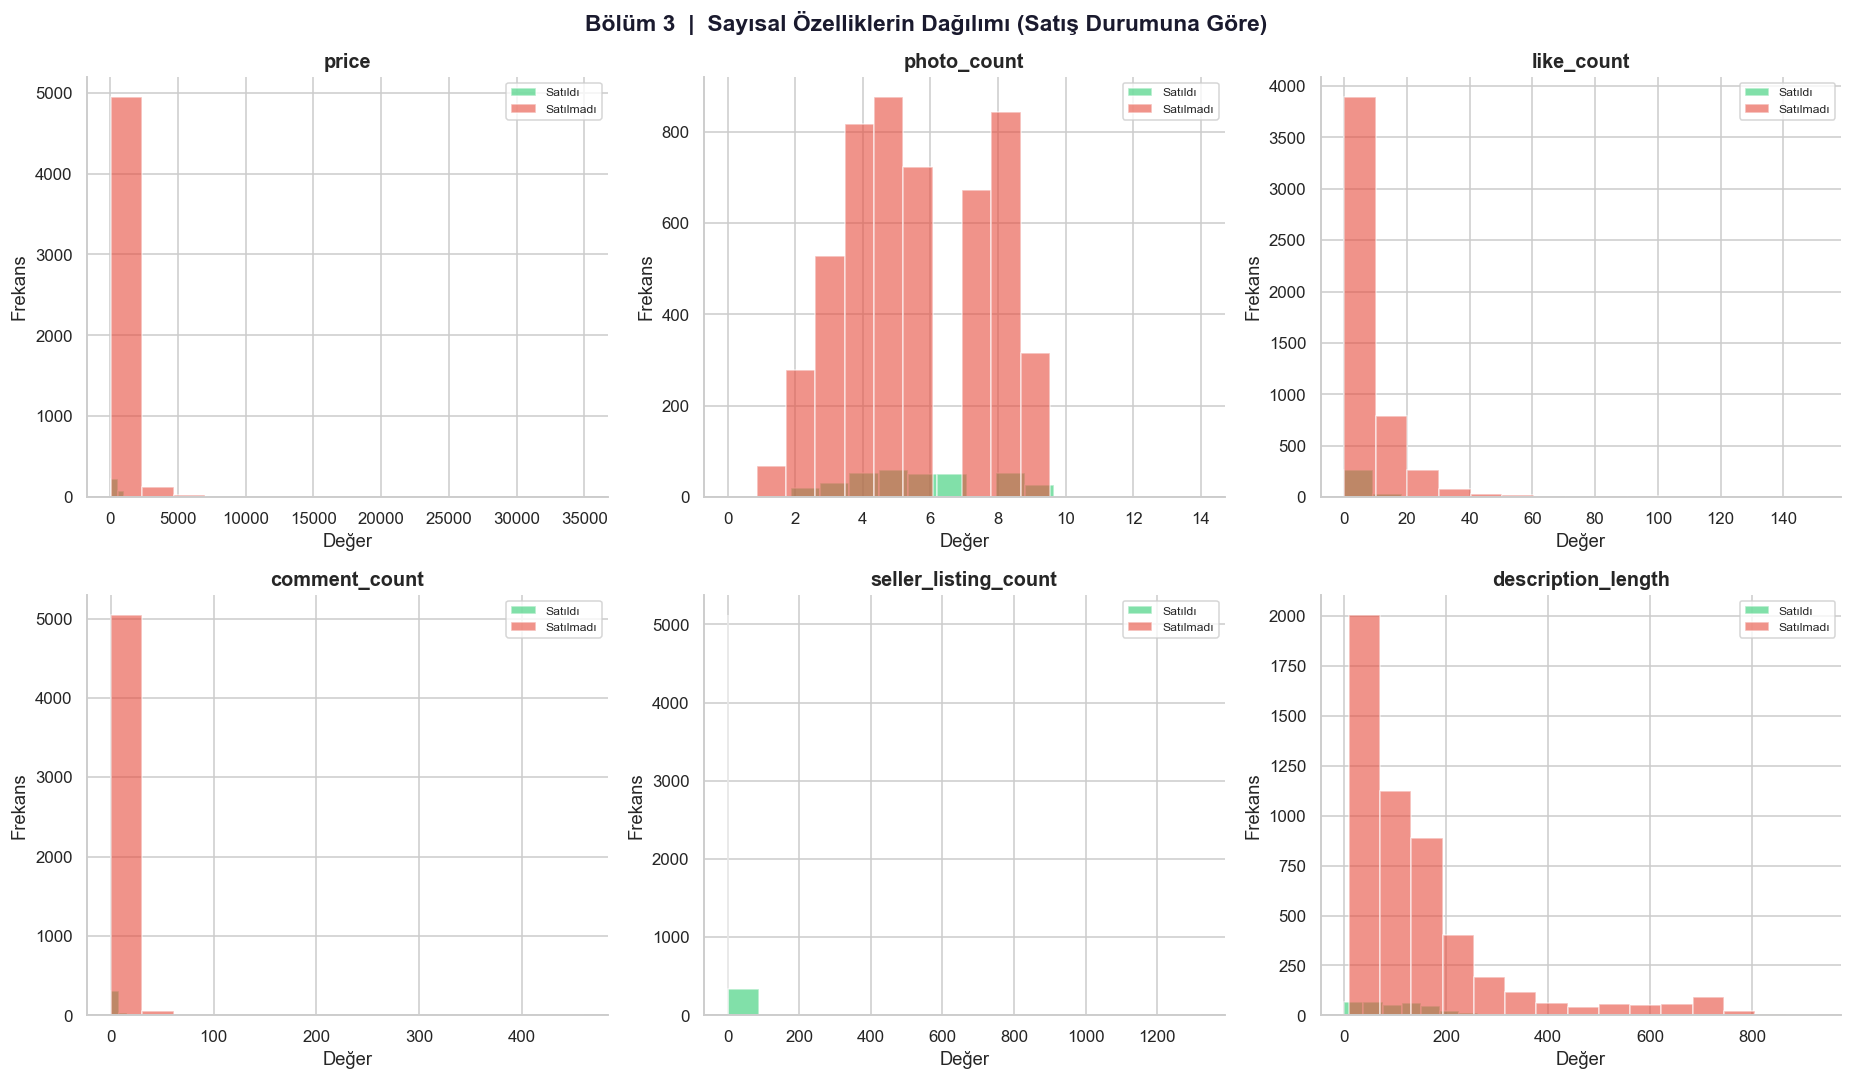

In [8]:
# ── Dağılım grafikleri — hedef bazında renklendirme ─────────────────────
plot_cols = ["price", "photo_count", "like_count", "comment_count",
             "seller_listing_count", "description_length"]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Bölüm 3  |  Sayısal Özelliklerin Dağılımı (Satış Durumuna Göre)",
             fontsize=15, fontweight="bold", color=DARK)
flat = axes.flatten()

for i, col in enumerate(plot_cols):
    ax = flat[i]
    sub = df_labeled[[col, "sold_within_7_days"]].dropna()
    for val, label, c in [(1, "Satıldı", GREEN), (0, "Satılmadı", RED)]:
        data = sub.loc[sub["sold_within_7_days"] == val, col]
        ax.hist(data, bins=15, alpha=0.6, color=c, label=label, edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("Değer")
    ax.set_ylabel("Frekans")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(Path("../artifacts/figures/eda/fig_numeric_distributions.png"), bbox_inches="tight"); plt.show()


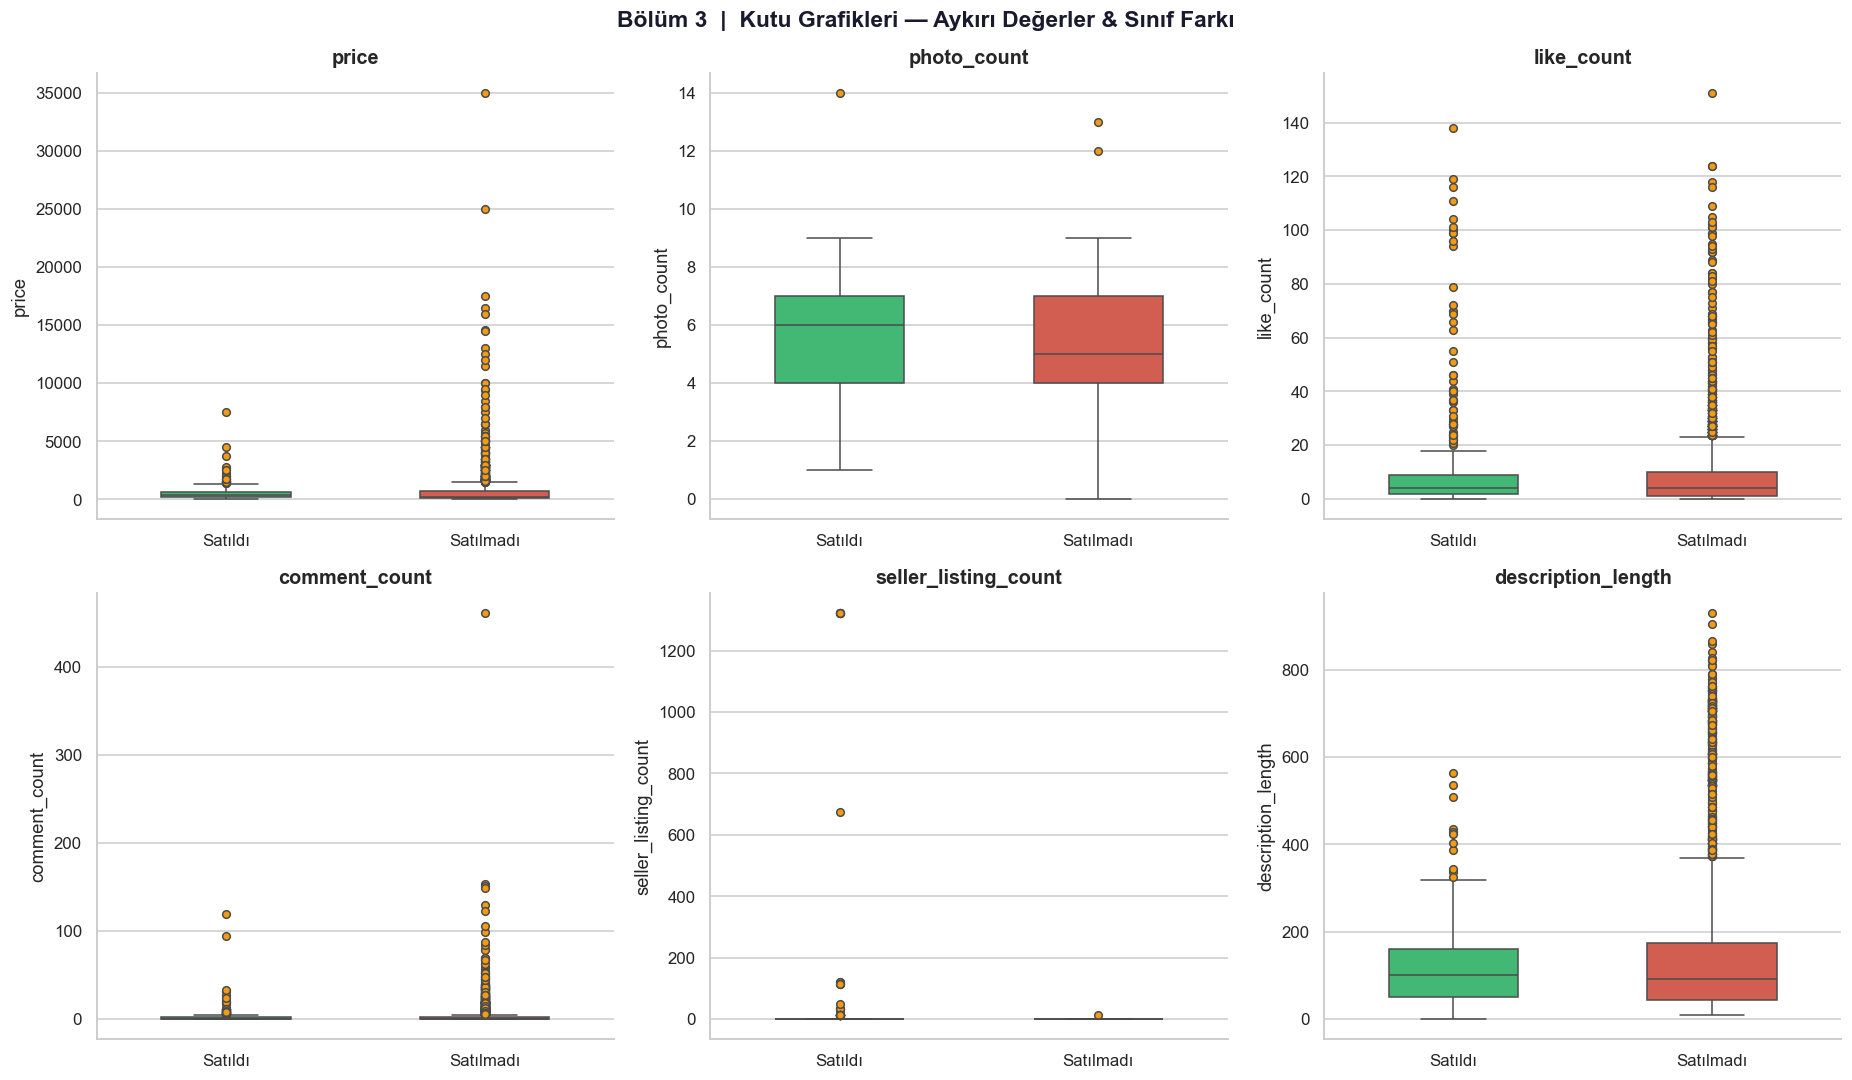

In [9]:
# ── Box plot — aykırı değer + sınıf karşılaştırması ─────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Bölüm 3  |  Kutu Grafikleri — Aykırı Değerler & Sınıf Farkı",
             fontsize=15, fontweight="bold", color=DARK)
flat = axes.flatten()

for i, col in enumerate(plot_cols):
    ax = flat[i]
    sub = df_labeled[[col, "sold_within_7_days"]].dropna()
    sub["Satış"] = sub["sold_within_7_days"].map({1: "Satıldı", 0: "Satılmadı"})
    sns.boxplot(data=sub, x="Satış", y=col, palette=[GREEN, RED], ax=ax, width=0.5,
                flierprops=dict(marker="o", markerfacecolor=ORANGE, markersize=5))
    ax.set_title(col)
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig(Path("../artifacts/figures/eda/fig_boxplots.png"), bbox_inches="tight"); plt.show()


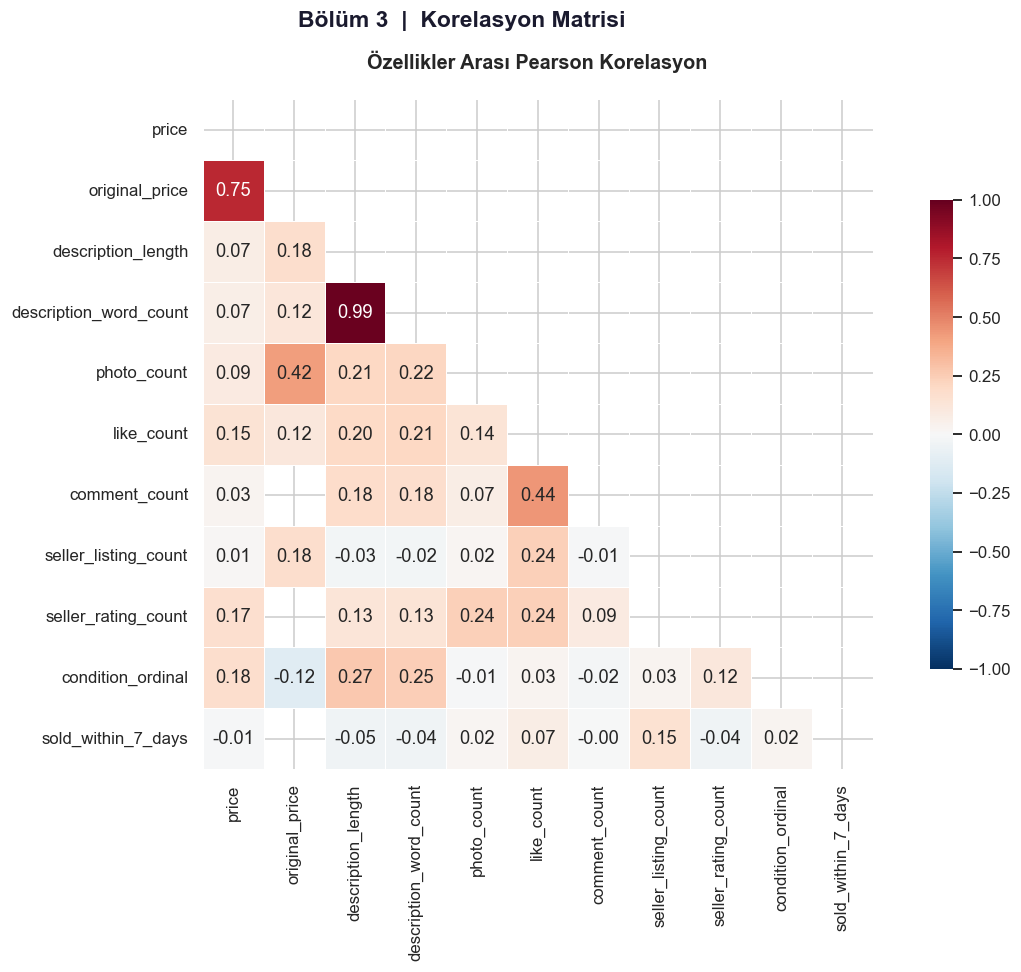


🎯  Hedef değişkenle korelasyon (mutlak değer):
seller_listing_count      0.151682
like_count                0.073394
description_length        0.045228
description_word_count    0.040637
seller_rating_count       0.040065
condition_ordinal         0.024436
photo_count               0.020394
price                     0.011292
comment_count             0.001948
original_price                 NaN


In [10]:
# ── Korelasyon ısı haritası ──────────────────────────────────────────────
corr_df = df_labeled[numeric_cols + ["sold_within_7_days"]].dropna(how="all")
corr    = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
fig.suptitle("Bölüm 3  |  Korelasyon Matrisi", fontsize=15, fontweight="bold", color=DARK)

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.7})

ax.set_title("Özellikler Arası Pearson Korelasyon", pad=20)
plt.tight_layout()
plt.savefig(Path("../artifacts/figures/eda/fig_correlation.png"), bbox_inches="tight"); plt.show()

# Hedef ile korelasyon sıralaması
target_corr = corr["sold_within_7_days"].drop("sold_within_7_days").abs().sort_values(ascending=False)
print("\n🎯  Hedef değişkenle korelasyon (mutlak değer):")
print(target_corr.to_string())


---
## Bölüm 3.2 — Kategorik Özellik Analizi

<div class="callout">
Kategorik değişkenler — marka, kategori, ürün durumu, beden, kargo — satış tahmini için
kritik sinyaller barındırır. Her değişkeni hedef satış oranıyla birlikte inceliyoruz.
</div>


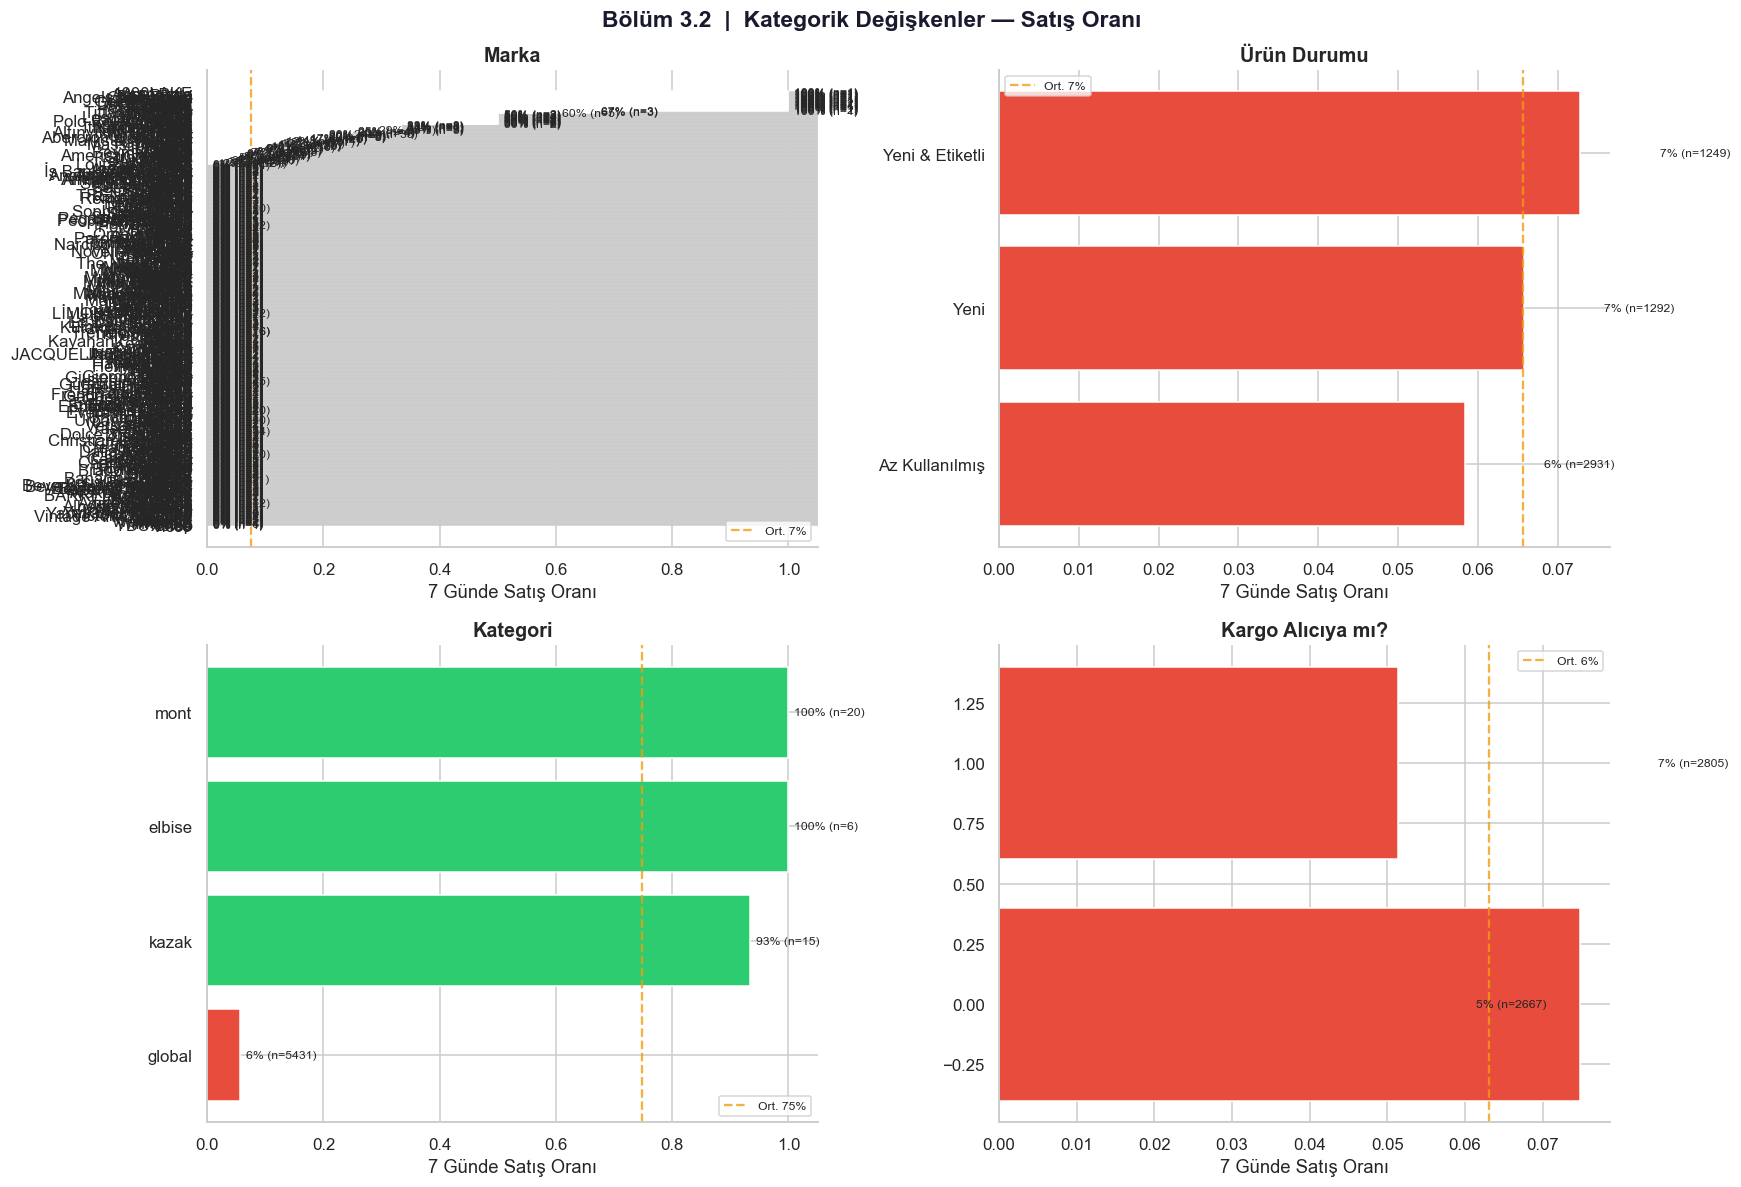

In [11]:
# ── Kategorik değişkenler — satış oranı analizi ──────────────────────────
cat_cols = ["brand_clean", "condition_clean", "category_scraped", "shipping_buyer_pays"]
labels   = ["Marka", "Ürün Durumu", "Kategori", "Kargo Alıcıya mı?"]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Bölüm 3.2  |  Kategorik Değişkenler — Satış Oranı",
             fontsize=15, fontweight="bold", color=DARK)
flat = axes.flatten()

for i, (col, lbl) in enumerate(zip(cat_cols, labels)):
    ax = flat[i]
    sub = df_labeled[[col, "sold_within_7_days"]].dropna()
    rate = sub.groupby(col)["sold_within_7_days"].agg(["mean", "count"])
    rate = rate.sort_values("mean", ascending=True)
    bars = ax.barh(rate.index, rate["mean"], color=[GREEN if v >= 0.5 else RED for v in rate["mean"]])
    ax.set_title(lbl)
    ax.set_xlabel("7 Günde Satış Oranı")
    ax.axvline(rate["mean"].mean(), color=ORANGE, linestyle="--", alpha=0.8, label=f"Ort. {rate['mean'].mean():.0%}")
    for j, (idx, row) in enumerate(rate.iterrows()):
        ax.text(row["mean"] + 0.01, j, f"{row['mean']:.0%} (n={row['count']:.0f})", va="center", fontsize=8)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(Path("../artifacts/figures/eda/fig_categorical_analysis.png"), bbox_inches="tight"); plt.show()


---
## Bölüm 4 — Feature Engineering

<div class="callout">
<b>Ham verideki anlam gizlidir.</b> Bu bölümde mevcut kolonları dönüştürüp yeni, anlamlı özellikler türetiyoruz.
Her feature'ın iş mantığını ve neden satış tahminine katkı sağlayabileceğini açıklıyoruz.<br><br>
<b>Strateji:</b> Fiyat sinyalleri → Satıcı profili → İlan kalitesi → Zaman → Metin analizi → Etkileşim terimleri
</div>

| Feature Grubu | Türetilen Özellikler | Beklenen Etki |
|---|---|---|
| **Fiyat** | `discount_ratio`, `price_log`, `is_price_outlier` | Daha ucuz & indirimli = daha hızlı satış |
| **Satıcı Profili** | `seller_tier`, `is_power_seller`, `seller_rating_count_log` | Güvenilir satıcı = daha hızlı satış |
| **İlan Kalitesi** | `photo_count_norm`, `has_real_desc`, `desc_quality_score` | Kaliteli ilan = daha hızlı satış |
| **Zaman** | `scrape_hour`, `scrape_dayofweek`, `is_weekend_scrape` | Hafta sonu ilanları farklı profil |
| **Etkileşim** | `price_x_condition`, `likes_per_photo` | Birleşik sinyaller daha güçlü |


In [12]:
# ══════════════════════════════════════════════════════════════════════════
#  FEATURE ENGINEERING — Dolap İlan Satış Tahmini
# ══════════════════════════════════════════════════════════════════════════
df_fe = df.copy()

# ── 1. ZAMAN ÖZELLİKLERİ ─────────────────────────────────────────────────
df_fe["scraped_at"] = pd.to_datetime(df_fe["scraped_at"])

df_fe["scrape_hour"]       = df_fe["scraped_at"].dt.hour
df_fe["scrape_dayofweek"]  = df_fe["scraped_at"].dt.dayofweek   # 0=Pzt, 6=Paz
df_fe["scrape_month"]      = df_fe["scraped_at"].dt.month
df_fe["is_weekend_scrape"] = (df_fe["scrape_dayofweek"] >= 5).astype(int)

# Gün içi segment (sabah/öğle/akşam/gece)
def hour_segment(h):
    if 6 <= h < 12:  return "sabah"
    elif 12 <= h < 18: return "öğle"
    elif 18 <= h < 23: return "akşam"
    else: return "gece"
df_fe["scrape_time_segment"] = df_fe["scrape_hour"].apply(hour_segment)

print("✅  Zaman özellikleri oluşturuldu")

# ── 2. FİYAT ÖZELLİKLERİ ─────────────────────────────────────────────────
# Log fiyat (sağ-çarpık dağılımı normalleştirmek için)
df_fe["price_log"]          = np.log1p(df_fe["price"])

# İndirim oranı (sadece original_price varsa)
df_fe["discount_ratio"] = np.where(
    df_fe["original_price"].notna() & (df_fe["original_price"] > df_fe["price"]),
    (df_fe["original_price"] - df_fe["price"]) / df_fe["original_price"],
    0.0
)

# Fiyat segmenti (ucuz/orta/pahalı)
q33 = df_fe["price"].quantile(0.33)
q67 = df_fe["price"].quantile(0.67)
def price_segment(p):
    if p <= q33: return "ucuz"
    elif p <= q67: return "orta"
    else: return "pahalı"
df_fe["price_segment"] = df_fe["price"].apply(price_segment)

print("✅  Fiyat özellikleri oluşturuldu")
print(f"    Fiyat segmentleri: ucuz <= {q33:.0f} TL, orta <= {q67:.0f} TL, pahalı > {q67:.0f} TL")

# ── 3. SATICI PROFİLİ ÖZELLİKLERİ ────────────────────────────────────────
# Satıcı tier (log-tabanlı)
def seller_tier(n):
    if n == 0:    return "yeni"
    elif n <= 10: return "başlangıç"
    elif n <= 50: return "orta"
    elif n <= 200: return "aktif"
    else:          return "power"
df_fe["seller_tier"]         = df_fe["seller_listing_count"].apply(seller_tier)
df_fe["is_power_seller"]     = (df_fe["seller_listing_count"] > 100).astype(int)
df_fe["seller_listing_log"]  = np.log1p(df_fe["seller_listing_count"])
df_fe["seller_rating_log"]   = np.log1p(df_fe["seller_rating_count"].fillna(0))

print("✅  Satıcı profili özellikleri oluşturuldu")

# ── 4. İLAN KALİTESİ ÖZELLİKLERİ ────────────────────────────────────────
# Gerçek açıklama var mı?
df_fe["has_real_desc"]    = (~df_fe["desc_is_placeholder"]).astype(int)

# Fotoğraf kalite skoru (log-normalize)
df_fe["photo_score"]      = np.log1p(df_fe["photo_count"])

# Açıklama kalite skoru (kelime sayısı + uzunluk birleşimi, sadece gerçek açıklamalar için)
df_fe["desc_quality_score"] = np.where(
    df_fe["has_real_desc"] == 1,
    np.log1p(df_fe["description_word_count"]) * np.log1p(df_fe["description_length"]),
    0
)

# İlan ilgi skoru (like + comment ağırlıklı)
df_fe["engagement_score"] = df_fe["like_count"] * 1.0 + df_fe["comment_count"] * 2.0
df_fe["likes_per_photo"]  = df_fe["like_count"] / df_fe["photo_count"].replace(0, 1)

print("✅  İlan kalitesi özellikleri oluşturuldu")

# ── 5. ETKİLEŞİM (INTERACTION) TERİMLERİ ────────────────────────────────
# Fiyat × Durum: ucuz + iyi durum = hızlı satış sinyali
df_fe["price_x_condition"]  = df_fe["price_log"] * df_fe["condition_ordinal"]

# Power satıcı + ucuz ilan kombinasyonu
df_fe["power_seller_cheap"] = ((df_fe["is_power_seller"] == 1) &
                               (df_fe["price_segment"] == "ucuz")).astype(int)

# Kargo ücretsiz + yeni ürün
df_fe["free_ship_new"]      = ((~df_fe["shipping_buyer_pays"]) &
                               (df_fe["condition_ordinal"] == 3)).astype(int)

print("✅  Etkileşim özellikleri oluşturuldu")

# ── ÖZET ─────────────────────────────────────────────────────────────────
new_features = ["scrape_hour","scrape_dayofweek","is_weekend_scrape","scrape_time_segment",
                "price_log","discount_ratio","price_segment",
                "seller_tier","is_power_seller","seller_listing_log","seller_rating_log",
                "has_real_desc","photo_score","desc_quality_score","engagement_score","likes_per_photo",
                "price_x_condition","power_seller_cheap","free_ship_new"]

print(f"\n📐  Toplam yeni özellik sayısı: {len(new_features)}")
print("    Yeni özellikler:", new_features)


✅  Zaman özellikleri oluşturuldu
✅  Fiyat özellikleri oluşturuldu
    Fiyat segmentleri: ucuz <= 190 TL, orta <= 599 TL, pahalı > 599 TL
✅  Satıcı profili özellikleri oluşturuldu
✅  İlan kalitesi özellikleri oluşturuldu
✅  Etkileşim özellikleri oluşturuldu

📐  Toplam yeni özellik sayısı: 19
    Yeni özellikler: ['scrape_hour', 'scrape_dayofweek', 'is_weekend_scrape', 'scrape_time_segment', 'price_log', 'discount_ratio', 'price_segment', 'seller_tier', 'is_power_seller', 'seller_listing_log', 'seller_rating_log', 'has_real_desc', 'photo_score', 'desc_quality_score', 'engagement_score', 'likes_per_photo', 'price_x_condition', 'power_seller_cheap', 'free_ship_new']


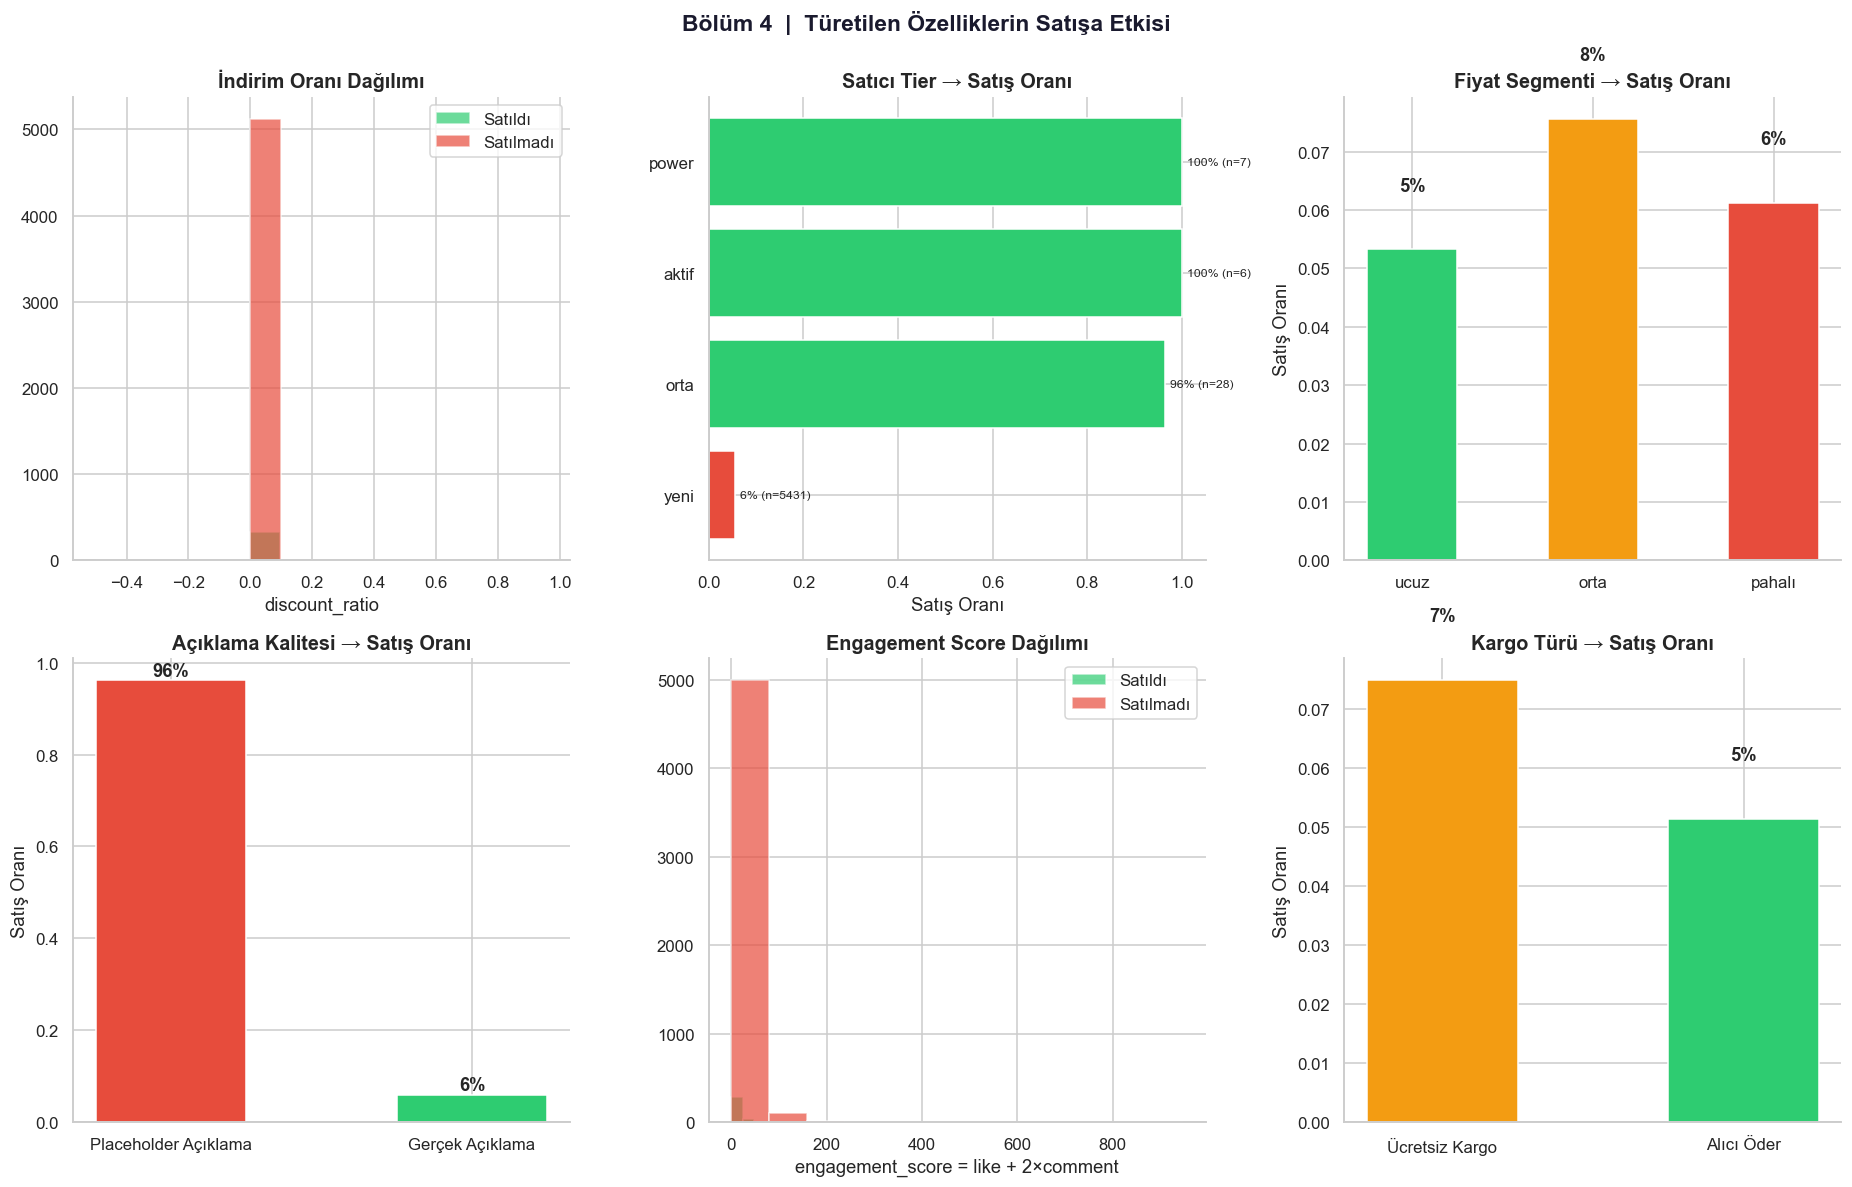

In [13]:
# ── Feature Engineering görselleştirmesi ─────────────────────────────────
df_fe_labeled = df_fe.dropna(subset=["sold_within_7_days"]).copy()
df_fe_labeled["sold_within_7_days"] = df_fe_labeled["sold_within_7_days"].astype(int)
df_fe_labeled["Satış"] = df_fe_labeled["sold_within_7_days"].map({1: "Satıldı ✅", 0: "Satılmadı ❌"})

fig, axes = plt.subplots(2, 3, figsize=(17, 11))
fig.suptitle("Bölüm 4  |  Türetilen Özelliklerin Satışa Etkisi",
             fontsize=15, fontweight="bold", color=DARK)
flat = axes.flatten()

# 1. İndirim oranı dağılımı
ax = flat[0]
for val, lbl, c in [(1,"Satıldı",GREEN),(0,"Satılmadı",RED)]:
    data = df_fe_labeled.loc[df_fe_labeled["sold_within_7_days"]==val, "discount_ratio"]
    ax.hist(data, bins=10, alpha=0.7, color=c, label=lbl, edgecolor="white")
ax.set_title("İndirim Oranı Dağılımı")
ax.set_xlabel("discount_ratio")
ax.legend()

# 2. Satıcı tier × satış oranı
ax = flat[1]
tier_rate = (df_fe_labeled.groupby("seller_tier")["sold_within_7_days"]
             .agg(["mean","count"]).rename(columns={"mean":"oran","count":"n"})
             .sort_values("oran", ascending=True))
ax.barh(tier_rate.index, tier_rate["oran"],
        color=[GREEN if v >= 0.5 else RED for v in tier_rate["oran"]])
ax.set_title("Satıcı Tier → Satış Oranı")
ax.set_xlabel("Satış Oranı")
for j,(idx,row) in enumerate(tier_rate.iterrows()):
    ax.text(row["oran"]+0.01, j, f"{row['oran']:.0%} (n={row['n']:.0f})", va="center", fontsize=8)

# 3. Fiyat segmenti × satış oranı
ax = flat[2]
seg_rate = (df_fe_labeled.groupby("price_segment")["sold_within_7_days"]
            .agg(["mean","count"]).rename(columns={"mean":"oran","count":"n"}))
seg_order = ["ucuz","orta","pahalı"]
seg_rate  = seg_rate.reindex([s for s in seg_order if s in seg_rate.index])
ax.bar(seg_rate.index, seg_rate["oran"], color=[GREEN,ORANGE,RED][:len(seg_rate)], width=0.5)
ax.set_title("Fiyat Segmenti → Satış Oranı")
ax.set_ylabel("Satış Oranı")
for j,(idx,row) in enumerate(seg_rate.iterrows()):
    ax.text(j, row["oran"]+0.01, f"{row['oran']:.0%}", ha="center", fontweight="bold")

# 4. Gerçek açıklama var mı?
ax = flat[3]
desc_rate = df_fe_labeled.groupby("has_real_desc")["sold_within_7_days"].agg(["mean","count"])
ax.bar(["Placeholder Açıklama", "Gerçek Açıklama"], desc_rate["mean"].values,
       color=[RED, GREEN], width=0.5)
ax.set_title("Açıklama Kalitesi → Satış Oranı")
ax.set_ylabel("Satış Oranı")
for j, v in enumerate(desc_rate["mean"].values):
    ax.text(j, v+0.01, f"{v:.0%}", ha="center", fontweight="bold")

# 5. Engagement score
ax = flat[4]
for val, lbl, c in [(1,"Satıldı",GREEN),(0,"Satılmadı",RED)]:
    data = df_fe_labeled.loc[df_fe_labeled["sold_within_7_days"]==val, "engagement_score"]
    ax.hist(data, bins=12, alpha=0.7, color=c, label=lbl, edgecolor="white")
ax.set_title("Engagement Score Dağılımı")
ax.set_xlabel("engagement_score = like + 2×comment")
ax.legend()

# 6. Kargo türü × satış
ax = flat[5]
ship_rate = df_fe_labeled.groupby("shipping_buyer_pays")["sold_within_7_days"].agg(["mean","count"])
ship_lbls  = {True:"Alıcı Öder", False:"Ücretsiz Kargo"}
ax.bar([ship_lbls[k] for k in ship_rate.index], ship_rate["mean"].values,
       color=[ORANGE, GREEN][:len(ship_rate)], width=0.5)
ax.set_title("Kargo Türü → Satış Oranı")
ax.set_ylabel("Satış Oranı")
for j, v in enumerate(ship_rate["mean"].values):
    ax.text(j, v+0.01, f"{v:.0%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(Path("../artifacts/figures/eda/fig_feature_engineering.png"), bbox_inches="tight"); plt.show()


In [ ]:
# ── Feature korelasyon sıralaması (hedef ile) ────────────────────────────
fe_numeric = ["price_log","discount_ratio","seller_listing_log","seller_rating_log",
              "photo_score","desc_quality_score","engagement_score","likes_per_photo",
              "price_x_condition","is_power_seller","has_real_desc","free_ship_new",
              "shipping_buyer_pays","condition_ordinal","is_weekend_scrape"]

fe_df = df_fe_labeled[fe_numeric + ["sold_within_7_days"]].copy()
fe_df["shipping_buyer_pays"] = fe_df["shipping_buyer_pays"].astype(int)

feat_corr = fe_df.corr()["sold_within_7_days"].drop("sold_within_7_days").sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle("Bölüm 4  |  Özellik-Hedef Korelasyon Sıralaması",
             fontsize=15, fontweight="bold", color=DARK)
colors = [GREEN if v > 0 else RED for v in feat_corr.values]
ax.barh(feat_corr.index, feat_corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(0.1, color=ORANGE, linewidth=1, linestyle="--", alpha=0.6, label="Eşik: |r| = 0.1")
ax.axvline(-0.1, color=ORANGE, linewidth=1, linestyle="--", alpha=0.6)
ax.set_xlabel("Pearson Korelasyon (hedef ile)")
ax.set_title("Pozitif = Satışı artırır | Negatif = Satışı azaltır")
ax.legend()
for i, v in enumerate(feat_corr.values):
    ax.text(v + (0.005 if v >= 0 else -0.005), i, f"{v:.3f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.savefig(Path("../artifacts/figures/eda/fig_feature_importance.png"), bbox_inches="tight"); plt.show()


---
## Bölüm 5 — Preprocessing (Ön İşleme)

<div class="callout">
Feature engineering tamamlandıktan sonra veriyi modele verebilmek için
son ön işleme adımlarını uyguluyoruz: <b>imputation → encoding → scaling</b>.
</div>

| Adım | Yöntem | Neden? |
|---|---|---|
| **Eksik değer** | Median imputation | Aykırı değerlere dayanıklı |
| **Ordinal encoding** | Manuel mapping | Sıra bilgisini korur |
| **One-hot encoding** | `pd.get_dummies` | Nominal kategoriler için |
| **Ölçekleme** | StandardScaler | SVM, LR, KNN gibi modeller için |
| **Leak kontrolü** | Sütun eleme | `is_sold`, `status`, `label_status` çıkarılır |


In [14]:
# ══════════════════════════════════════════════════════════════════════════
#  PREPROCESSING — Dolap İlan Satış Tahmini
# ══════════════════════════════════════════════════════════════════════════

# ── Sızıntı riski taşıyan kolonları çıkar ────────────────────────────────
LEAK_COLS  = ["is_sold","status","label_status","label_source","checked_at",
              "has_real_label","sold_within_7_days"]  # target ayrı tutulacak
META_COLS  = ["url","listing_id","seller_username","scraped_at","cohort_id",
              "category_path","category","subcategory","brand","title",
              "description_text","color","size","shipping_info",
              "original_price","category_scraped"]

KEEP_NUMERIC = ["price_log","discount_ratio","seller_listing_log","seller_rating_log",
                "photo_score","desc_quality_score","engagement_score","likes_per_photo",
                "price_x_condition","condition_ordinal","scrape_hour","scrape_dayofweek"]

KEEP_BINARY  = ["is_power_seller","has_real_desc","is_weekend_scrape",
                "shipping_buyer_pays","free_ship_new","power_seller_cheap",
                "is_price_outlier","is_like_outlier"]

KEEP_CATEG   = ["brand_clean","seller_tier","price_segment","scrape_time_segment",
                "condition_clean"]

TARGET       = "sold_within_7_days"

# Etiketli veri seç
df_model = df_fe_labeled[KEEP_NUMERIC + KEEP_BINARY + KEEP_CATEG + [TARGET]].copy()
df_model[TARGET] = df_model[TARGET].astype(int)
df_model["shipping_buyer_pays"] = df_model["shipping_buyer_pays"].astype(int)

print(f"Model veri boyutu: {df_model.shape}")
print(f"Eksik değer sayısı:\n{df_model.isnull().sum()[df_model.isnull().sum() > 0]}")

# ── Median imputation ─────────────────────────────────────────────────────
imputer = SimpleImputer(strategy="median")
df_model[KEEP_NUMERIC] = imputer.fit_transform(df_model[KEEP_NUMERIC])
print("\n✅  Eksik değerler median ile dolduruldu")

# ── One-hot encoding ──────────────────────────────────────────────────────
df_encoded = pd.get_dummies(df_model, columns=KEEP_CATEG, drop_first=False, dtype=int)
print(f"✅  Kategorik encoding sonrası boyut: {df_encoded.shape}")

# ── Ölçekleme ─────────────────────────────────────────────────────────────
feature_cols = [c for c in df_encoded.columns if c != TARGET]
X = df_encoded[feature_cols].values
y = df_encoded[TARGET].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅  StandardScaler uygulandı")
print(f"\n🎯  Final feature matrisi: {X_scaled.shape} | Hedef: {y.shape}")
print(f"    Pozitif sınıf oranı: {y.mean():.1%}")


Model veri boyutu: (5472, 26)
Eksik değer sayısı:
Series([], dtype: int64)

✅  Eksik değerler median ile dolduruldu
✅  Kategorik encoding sonrası boyut: (5472, 584)
✅  StandardScaler uygulandı

🎯  Final feature matrisi: (5472, 583) | Hedef: (5472,)
    Pozitif sınıf oranı: 6.3%


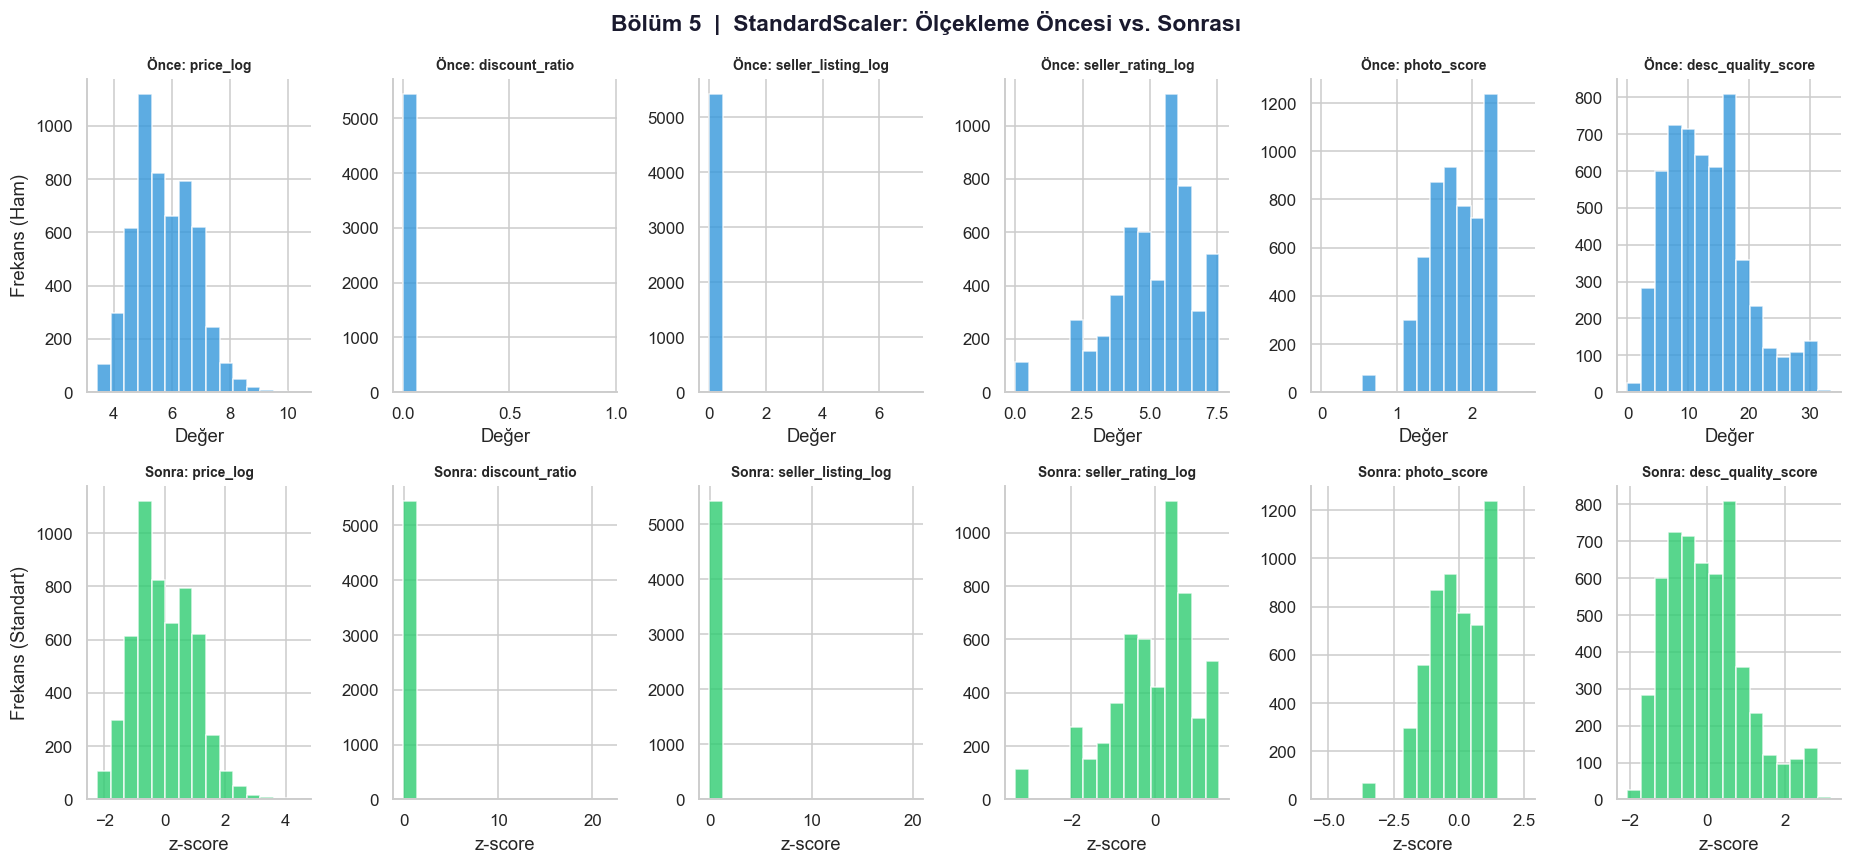

In [15]:
# ── Ölçekleme öncesi/sonrası görselleştirme ──────────────────────────────
show_cols = KEEP_NUMERIC[:6]
show_idx  = [list(df_encoded.columns[:-1]).index(c) for c in show_cols if c in df_encoded.columns]

fig, axes = plt.subplots(2, len(show_idx), figsize=(17, 8))
fig.suptitle("Bölüm 5  |  StandardScaler: Ölçekleme Öncesi vs. Sonrası",
             fontsize=15, fontweight="bold", color=DARK)

for j, (col, idx) in enumerate(zip(show_cols, show_idx)):
    axes[0, j].hist(X[:, idx], bins=15, color=BLUE, edgecolor="white", alpha=0.8)
    axes[0, j].set_title(f"Önce: {col}", fontsize=9)
    axes[0, j].set_xlabel("Değer")

    axes[1, j].hist(X_scaled[:, idx], bins=15, color=GREEN, edgecolor="white", alpha=0.8)
    axes[1, j].set_title(f"Sonra: {col}", fontsize=9)
    axes[1, j].set_xlabel("z-score")

axes[0, 0].set_ylabel("Frekans (Ham)")
axes[1, 0].set_ylabel("Frekans (Standart)")

plt.tight_layout()
plt.savefig(Path("../artifacts/figures/eda/fig_scaling.png"), bbox_inches="tight"); plt.show()


Aykırı Değer Özeti:


,lower,upper,outlier_count,pct
price,-737.5,1642.5,312,5.1%
like_count,-12.5,23.5,416,6.9%
seller_listing_count,0.0,0.0,43,0.7%
engagement_score,-20.0,36.0,542,8.9%


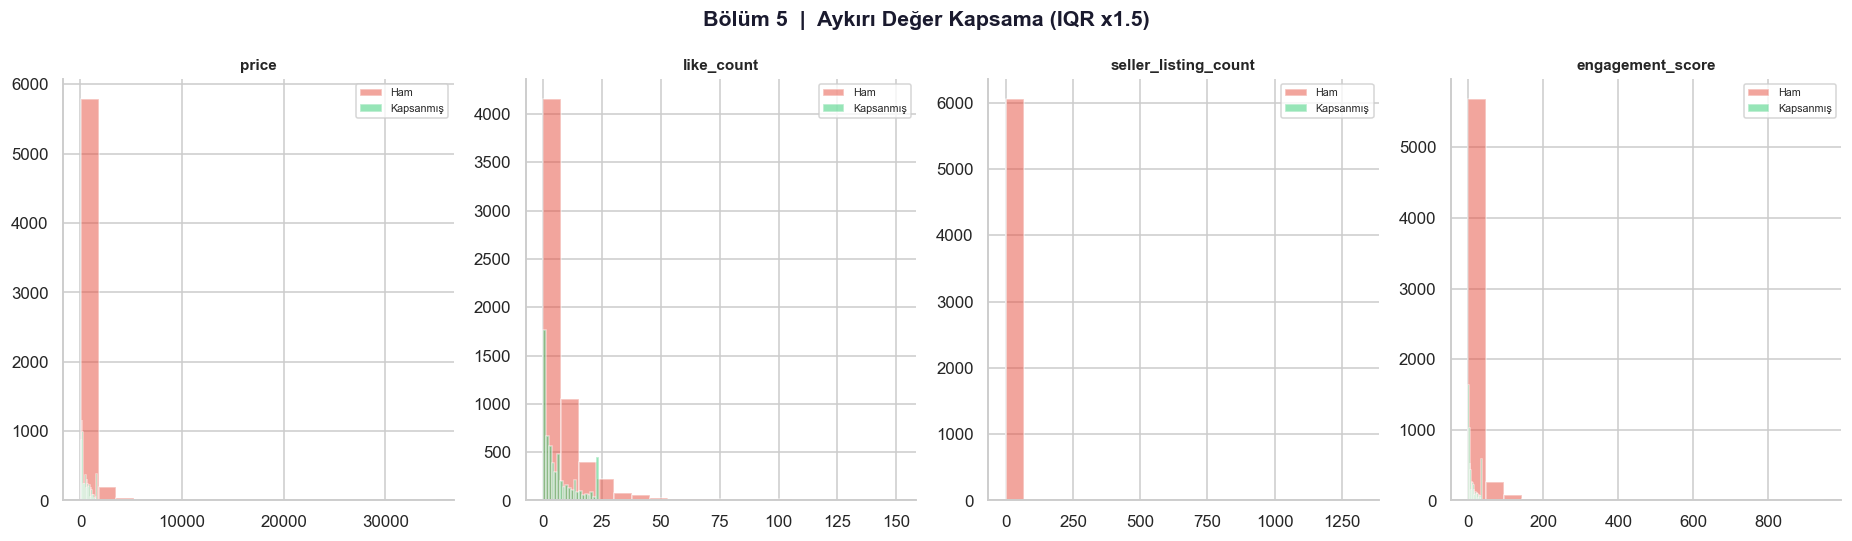

In [16]:
# ── Aykırı değer tespiti & kapsama (IQR yöntemi) ─────────────────────────
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outlier_summary = {}
for col in ["price", "like_count", "seller_listing_count", "engagement_score"]:
    if col in df_fe.columns:
        lo, hi = iqr_bounds(df_fe[col].dropna())
        n_out  = ((df_fe[col] < lo) | (df_fe[col] > hi)).sum()
        outlier_summary[col] = {"lower": lo, "upper": hi, "outlier_count": n_out,
                                "pct": n_out / len(df_fe) * 100}

out_df = pd.DataFrame(outlier_summary).T
print("Aykırı Değer Özeti:")
display(out_df.style
        .background_gradient(subset=["pct"], cmap="YlOrRd")
        .format({"lower":"{:.1f}","upper":"{:.1f}","outlier_count":"{:.0f}","pct":"{:.1f}%"})
        .set_table_styles([{"selector":"th","props":[("background","#1a1a2e"),("color","white")]}]))

# Kapsama görselleştirmesi
fig, axes = plt.subplots(1, 4, figsize=(17, 5))
fig.suptitle("Bölüm 5  |  Aykırı Değer Kapsama (IQR x1.5)", fontsize=14, fontweight="bold", color=DARK)
for i, col in enumerate(outlier_summary.keys()):
    ax = axes[i]
    raw    = df_fe[col].dropna()
    lo, hi = outlier_summary[col]["lower"], outlier_summary[col]["upper"]
    capped = raw.clip(lower=lo, upper=hi)
    ax.hist(raw,    bins=20, alpha=0.5, color=RED,   label="Ham",    edgecolor="white")
    ax.hist(capped, bins=20, alpha=0.5, color=GREEN, label="Kapsanmış", edgecolor="white")
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(Path("../artifacts/figures/eda/fig_outlier_capping.png"), bbox_inches="tight"); plt.show()


---
## Bölüm 6 — Pipeline Özeti & Sonraki Adımlar

<div class="success">
EDA ve preprocessing aşamaları tamamlandı! Veriden modele hazır feature matrisi elde edildi.
</div>

| Aşama | Çıktı |
|---|---|
| **Problem Tanımı** | Binary sınıflandırma: `sold_within_7_days` (0/1) |
| **Veri Keşfi** | 42 kolon → temizleme sonrası model-ready set |
| **Eksik Değer** | `category`, `original_price` eksik → median imputation / drop |
| **Feature Engineering** | 19 yeni özellik türetildi (zaman, fiyat, satıcı, kalite, etkileşim) |
| **Encoding** | One-hot encoding + ordinal mapping |
| **Ölçekleme** | StandardScaler |
| **Sızıntı Kontrolü** | `is_sold`, `status`, `label_status` eğitimden çıkarıldı |

### ⚠️  Kritik Notlar (Gerçek 6000 Satırlık Veri İçin)
1. **Sınıf dengesizliği**: Satış oranı düşükse → SMOTE veya class_weight ayarı gerekli
2. **Zaman sızıntısı**: Train/test split zaman bazlı yapılmalı (rastgele değil!)
3. **Satıcı bilgisi**: Aynı satıcının birden fazla ilanı var → group-based CV önerilir
4. **`PAYLA` beden değeri**: Gerçek veri temizliğinde bu değer NaN olarak işaretlenmeli

### 🚀  Sonraki Adımlar
- [ ] Zaman bazlı train/test split
- [ ] Dengesiz sınıf için SMOTE veya oversampling
- [ ] Baseline model: Logistic Regression, Random Forest
- [ ] Hyperparameter tuning: XGBoost / LightGBM
- [ ] SHAP ile model yorumlanabilirliği


In [ ]:
# ── Final feature matrisi özeti ──────────────────────────────────────────
print("=" * 55)
print("  DOLAP EDA — FİNAL MODEL GİRDİSİ ÖZETİ")
print("=" * 55)
print(f"  Satır sayısı    : {X_scaled.shape[0]}")
print(f"  Özellik sayısı  : {X_scaled.shape[1]}")
print(f"  Hedef: sold_within_7_days")
print(f"    - Pozitif (satıldı)  : {y.sum()} ({y.mean():.1%})")
print(f"    - Negatif (satılmadı): {(1-y).sum()} ({(1-y).mean():.1%})")
print()
print("  Özellik listesi:")
for i, col in enumerate(feature_cols):
    print(f"    {i+1:2d}. {col}")
print()
print("  ✅  Veri modele hazır!")
